In [1]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence # http://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html

In [2]:
def collate_fn_transformer(batch):
    """
    Custom function that defines how batches are formed.

    To process the batch items that each have a different number of hits, it is efficient
    to first concatenate all the data into a single tensor and save the lengths of each
    individual event to be able to split the data again later.

    # F: input_dim, number of features (time, x, y)
    # N: number of hits (different for each event)
    # B: batch size

    The resulting 2D tensor has the shape (B x N, F) where B is the batch size, N is the total number of hits of all events
    in the batch, and F is the number of features (time, x, y).


    Parameters
    ----------
    batch : list
        A list of dictionaries containing the data and labels for each graph.
        The data is available in the "data" key and the labels are in the "xpos" and "ypos" keys.
    Returns
    -------
    packed_data : Batch
        A batch of graph data objects.
    labels : torch.Tensor
        A tensor containing the labels for each graph.
    """
    data_list = []
    labels = []
    lengths=[]

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits)
        # where the feautures are (time, x, y)
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensordata = tensordata.to(dtype=torch.float32)

        lengths.append(tensordata.shape[0])

        data_list.append(tensordata)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0) # convert the list of tensors to a single tensor

    data_vec=torch.cat(data_list) # (B, N, F)  -> (BxN, F) where B is the batch size, N is the number of hits, and F is the number of features (time, x, y)

    ## return a list [datalist, lengths]
    return [data_vec, lengths], labels

In [4]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim=3,
        d_model=32,
        nhead=2,
        dim_feedforward=64,
        num_layers=2,
        output_dim=2
    ):
        super().__init__()

        # Hint: define the input embedding layer
        self.input_emb = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(  # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            activation="relu",
            batch_first=True,
            norm_first=True,
            dropout=0.02
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers) # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html

        # Hint: define the output projection layer
        self.output_proj = nn.Linear(d_model, output_dim)

    def forward(self, data) -> torch.Tensor:
        """
        Args:
            data: list of (src tensor, lengths)
        Returns:
            Tensor of shape (batch, output_dim)
        """

        src, lengths = data

        # F: input_dim, number of features (time, x, y)
        # N: number of hits
        # D: hidden_dim, internal transformer computing dimension
        # B: batch size

        # 1) embed the input data into the hidden dimension
          # shape (B x N, F) -> (B x N, D)
        src = self.input_emb(src)

        # 2) split the data into a list of tensors, one for each event
        parts = src.split(lengths, dim=0)  # shape (B x N, D) -> (B, N, D), where every batch entry can have a variable length,
                                           # i.e., list of tensors of shape (N_i, D) where N_i is the number of hits in the i-th event


        # 3) pad inputs with zeros so that all batch items have same length
        padded = pad_sequence(parts, batch_first=True) # shape (B, N, D) -> (B x MAXLEN x D) now all batch entries have the same length
        batch_size, max_len, _ = padded.shape

        # 4) build the padding mask (batch_size, max_len)
        # we need to keep track which tokens are padding tokens and which are real tokens
        # the mask is a boolean tensor of shape (B, MAXLEN) where True indicates that the corresponding entry is a padding token
        # and False indicates that the corresponding entry is a real token
        # the mask is used to ignore the padding tokens in the attention mechanism
        mask = torch.zeros(batch_size, max_len, dtype=torch.bool).to(device=padded.device, dtype=torch.bool)
        for i, L in enumerate(lengths):
            mask[i, L:] = True

        # 5) call the transformer with padded tensor of shape (B, MAXLEN, D) and corresponding mask of shape (B, MAXLEN)
        enc_out = self.encoder(padded, src_key_padding_mask=mask)

        # 6) masked mean‐pool, i.e., form the average for every batch item along the sequence dimension
        # the output of the transformer is a tensor of shape (B, MAXLEN, D)
        # we need to take the mean over the sequence dimension (MAXLEN) to get a single vector for each batch item
        # we need to ignore the padding tokens in the mean pooling
        # the resulting shape is (B, D)
        valid_mask = ~mask
        summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1)
        pooled = summed / torch.LongTensor(lengths)[:,None].to(enc_out)

        # 7) apply a final linear layer to get the output of shape (B, output_dim)
        out = self.output_proj(pooled)
        return out

In [5]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader

class NeutrinoDataset(Dataset):
    def __init__(self, file_path):
        self.df = pd.read_parquet(file_path)
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "data": pd.DataFrame(np.stack(row["data"])), 
            "xpos": row["xpos"], 
            "ypos": row["ypos"]
        }

# Initialize datasets and dataloaders
train_dataset = NeutrinoDataset("data_pq/train.pq")
val_dataset = NeutrinoDataset("data_pq/val.pq")
test_dataset = NeutrinoDataset("data_pq/test.pq")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn_transformer)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn_transformer)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn_transformer)


In [7]:
import torch.optim as optim
import time

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Define the model, optimizer, and loss function
model = TransformerEncoder(input_dim=3, d_model=32, nhead=2, dim_feedforward=64, num_layers=2, output_dim=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    
    for batch_data, labels in train_loader:
        batch_data[0] = batch_data[0].to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        
    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_data, labels in val_loader:
            batch_data[0] = batch_data[0].to(device)
            labels = labels.to(device)
            outputs = model(batch_data)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * labels.size(0)
            
    epoch_val_loss = val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    
    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{epochs} | Train Loss (MSE): {epoch_train_loss:.4f} | Val Loss (MSE): {epoch_val_loss:.4f} | Time: {elapsed_time:.2f}s")


Using device: mps


/var/folders/4m/dpkc51pn50g5mtmjpw8dsqj80000gn/T/ipykernel_15085/2004448266.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers) # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html


Epoch 1/100 | Train Loss (MSE): 16.1456 | Val Loss (MSE): 6.8624 | Time: 6.71s
Epoch 2/100 | Train Loss (MSE): 5.9075 | Val Loss (MSE): 5.0378 | Time: 5.54s
Epoch 3/100 | Train Loss (MSE): 4.7383 | Val Loss (MSE): 4.3832 | Time: 5.44s
Epoch 4/100 | Train Loss (MSE): 4.2913 | Val Loss (MSE): 4.0276 | Time: 5.20s
Epoch 5/100 | Train Loss (MSE): 4.0290 | Val Loss (MSE): 3.8982 | Time: 5.02s
Epoch 6/100 | Train Loss (MSE): 3.8219 | Val Loss (MSE): 3.6445 | Time: 5.13s
Epoch 7/100 | Train Loss (MSE): 3.6484 | Val Loss (MSE): 3.6297 | Time: 5.20s
Epoch 8/100 | Train Loss (MSE): 3.5126 | Val Loss (MSE): 3.6008 | Time: 5.17s
Epoch 9/100 | Train Loss (MSE): 3.3767 | Val Loss (MSE): 3.3814 | Time: 5.04s
Epoch 10/100 | Train Loss (MSE): 3.3041 | Val Loss (MSE): 3.2327 | Time: 5.09s
Epoch 11/100 | Train Loss (MSE): 3.2017 | Val Loss (MSE): 3.0997 | Time: 5.97s
Epoch 12/100 | Train Loss (MSE): 3.1096 | Val Loss (MSE): 3.1596 | Time: 5.10s
Epoch 13/100 | Train Loss (MSE): 3.0143 | Val Loss (MSE): 3.

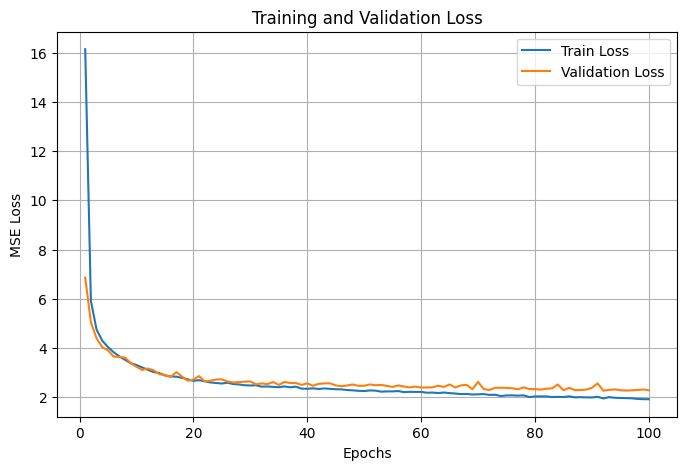

In [8]:
import matplotlib.pyplot as plt
import os

# Create folder to store visualization artifacts
os.makedirs('png', exist_ok=True)

# 1. Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('png/training_loss.png')
plt.show()


In [9]:
# 2. Test evaluation Metrics
model.eval()
all_preds = []
all_labels = []

test_loss = 0.0
with torch.no_grad():
    for batch_data, labels in test_loader:
        batch_data[0] = batch_data[0].to(device)
        labels = labels.to(device)
        outputs = model(batch_data)
        
        loss = criterion(outputs, labels)
        test_loss += loss.item() * labels.size(0)
        
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)


In [10]:

# Metrics calculation
mse_x = np.mean((all_preds[:, 0] - all_labels[:, 0])**2)
mse_y = np.mean((all_preds[:, 1] - all_labels[:, 1])**2)
mae_x = np.mean(np.abs(all_preds[:, 0] - all_labels[:, 0]))
mae_y = np.mean(np.abs(all_preds[:, 1] - all_labels[:, 1]))

print(f"Test Set Average MSE Loss: {test_loss / len(test_dataset):.4f}")
print(f"MSE X: {mse_x:.4f}, MAE X: {mae_x:.4f}")
print(f"MSE Y: {mse_y:.4f}, MAE Y: {mae_y:.4f}")


Test Set Average MSE Loss: 2.1849
MSE X: 1.6308, MAE X: 0.8585
MSE Y: 2.7390, MAE Y: 1.0276


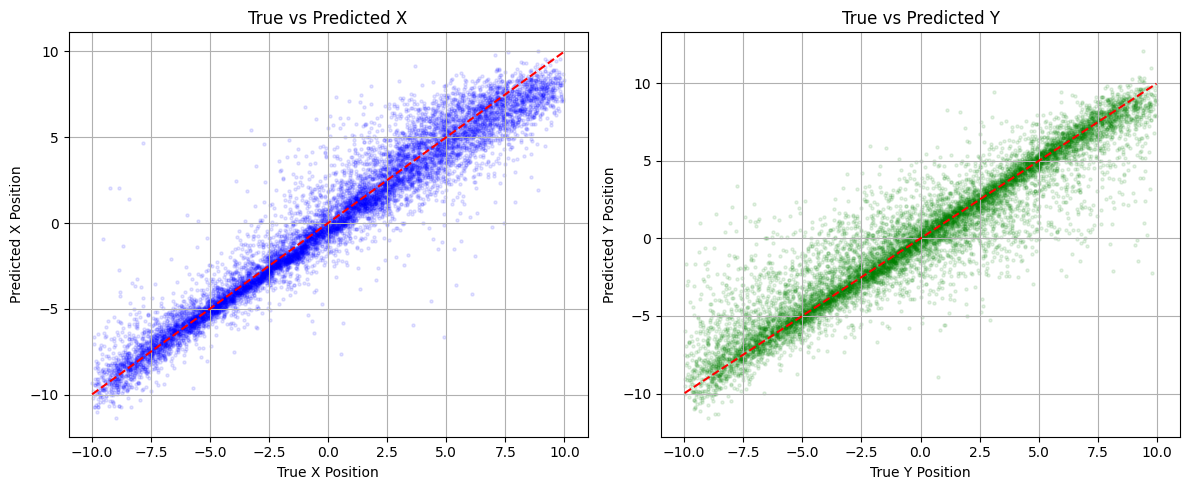

In [11]:
# 3. Plotting True vs Predicted positions
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(all_labels[:, 0], all_preds[:, 0], alpha=0.1, s=5, c='blue')
axs[0].plot([all_labels[:, 0].min(), all_labels[:, 0].max()], 
            [all_labels[:, 0].min(), all_labels[:, 0].max()], 'r--')
axs[0].set_xlabel('True X Position')
axs[0].set_ylabel('Predicted X Position')
axs[0].set_title('True vs Predicted X')
axs[0].grid(True)

axs[1].scatter(all_labels[:, 1], all_preds[:, 1], alpha=0.1, s=5, c='green')
axs[1].plot([all_labels[:, 1].min(), all_labels[:, 1].max()], 
            [all_labels[:, 1].min(), all_labels[:, 1].max()], 'r--')
axs[1].set_xlabel('True Y Position')
axs[1].set_ylabel('Predicted Y Position')
axs[1].set_title('True vs Predicted Y')
axs[1].grid(True)

plt.tight_layout()
plt.savefig('png/true_vs_pred.png')
plt.show()

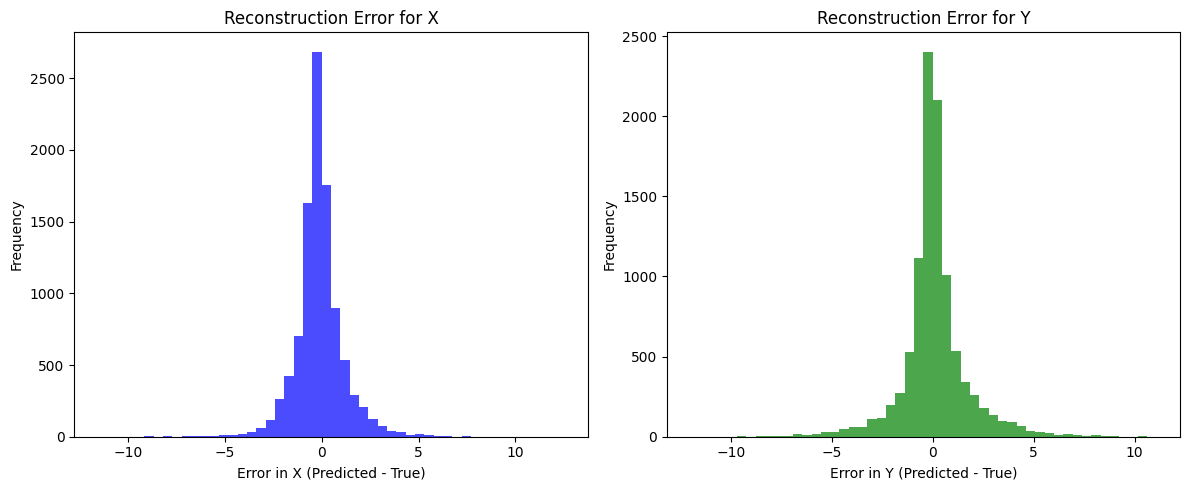

In [12]:

# 4. Plotting the reconstruction error distributions
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

error_x = all_preds[:, 0] - all_labels[:, 0]
axs[0].hist(error_x, bins=50, color='blue', alpha=0.7)
axs[0].set_xlabel('Error in X (Predicted - True)')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Reconstruction Error for X')

error_y = all_preds[:, 1] - all_labels[:, 1]
axs[1].hist(error_y, bins=50, color='green', alpha=0.7)
axs[1].set_xlabel('Error in Y (Predicted - True)')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Reconstruction Error for Y')

plt.tight_layout()
plt.savefig('png/error_distribution.png')
plt.show()


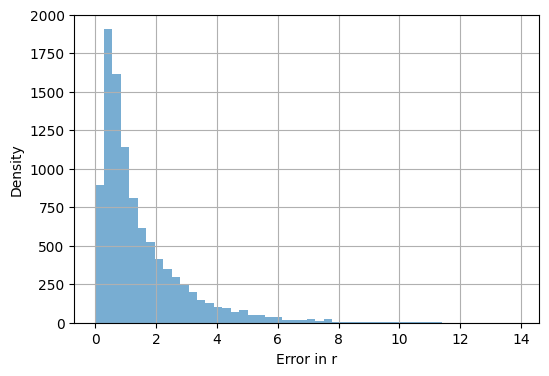

mean error r 1.4876765


In [13]:
res_r = np.sqrt((error_x)**2 +
(error_y)**2)
plt.figure(figsize=(6,4))
plt.hist(res_r, bins=50, alpha=0.6)
plt.xlabel("Error in r")
plt.ylabel("Density")
plt.grid(True)
plt.show()

mean_error = np.mean(res_r)
print('mean error r', mean_error)